<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic1.2-Linear_Algebra/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Linear Algebra

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic1.2-Linear_Algebra_Problems.zip) <archives/Topic1.2-Linear_Algebra_Problems.zip>` — the notebook and
`smr_ms.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Linear Algebra </1-numerical_methods/Topic1.2-Linear_Algebra>`.
It is worth **100 points**: **Part A** (30, auto-graded, unlimited attempts), **Part B**
(35, plots plus interpretation, peer graded) and **Part C** (35, open ended, peer graded).
The parts build on each other, so do them in order.

**No chemistry is required.** Every chemical fact you need is given to you below. The work
is linear algebra.
:::



## Setup

Steam methane reforming is how most of the world's hydrogen is made. **The reaction is:**

$$
\mathrm{CH_4} + \mathrm{H_2O} \;\longrightarrow\; 3\,\mathrm{H_2} + \mathrm{CO}
$$

The dataset is `data/smr_ms.csv`: a quadrupole mass spectrometer watching a catalytic
reactor outlet for 180 minutes as it lights off, sampling once a minute. Four channels,
one per species, recorded as **ion currents in mA**. It is inspired by a mass spectroscopy
measurement in the lab of Prof. Bjarne Kreitz at Georgia Tech.

An ion current is not a concentration: it is proportional to how much of a species is
present, but with a per-species constant nobody has calibrated here. Part C is about why
that matters.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/smr_ms.csv')
species = ['CH4', 'H2O', 'H2', 'CO']

t = df['t_min'].values
X = df[species].values          # 180 x 4: one column per species, in the order above
print(X.shape)
df.head()

(180, 4)


,t_min,CH4,H2O,H2,CO
0,0,0.73604,0.89408,-0.003929,-0.003459
1,1,0.74296,0.91777,-0.001942,0.001329
2,2,0.74234,0.89850,0.001058,0.007203
3,3,0.74588,0.89577,0.010228,0.012154
4,4,0.74625,0.89740,0.004382,-0.000570


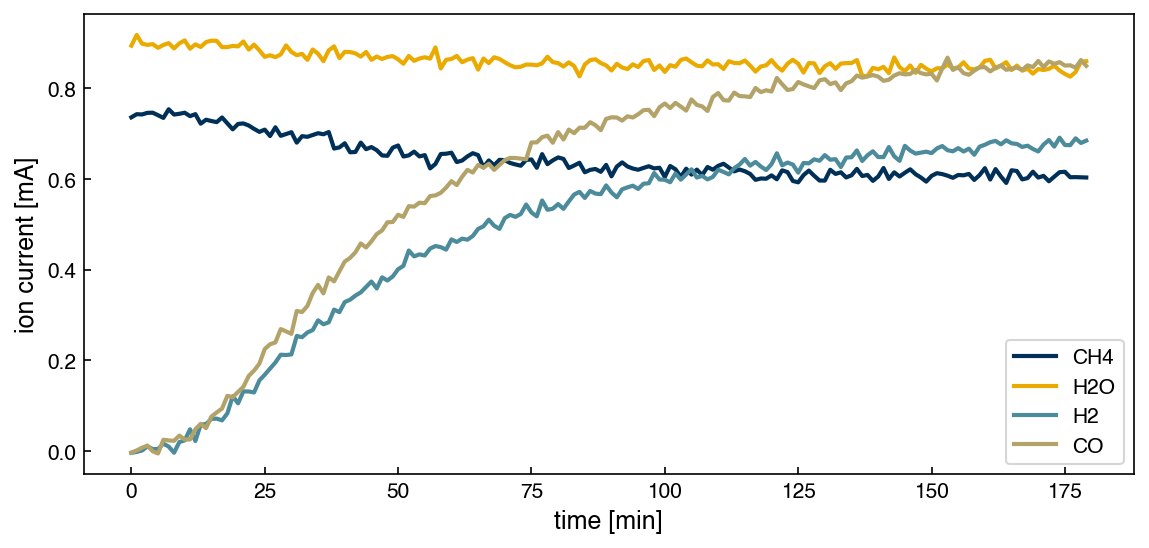

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for j in range(len(species)):
    ax.plot(t, X[:, j], label=species[j])
ax.set_xlabel('time [min]')
ax.set_ylabel('ion current [mA]')
ax.legend();

The reactor lights off early: H₂ and CO start climbing within the first twenty minutes,
are halfway up by about minute 42, and level off over the second half. CH₄ falls as they
rise. H₂O barely moves, because it is fed in large excess.

:::{admonition} The species order is fixed. Memorize it.
:class: warning

Every vector and every matrix column here is ordered
$\mathrm{CH_4}, \mathrm{H_2O}, \mathrm{H_2}, \mathrm{CO}$, matching the columns of `X`.
Nothing will warn you if you scramble it — you will just get a different number that looks
equally plausible. If an answer comes back wrong, check the ordering first.
:::

### Four species, four dimensions

Four species means a composition is **a vector of four numbers**, so every composition the
reactor could have is a point in **four-dimensional space**. Call it *species space*.

The bookkeeping is done by the **atom matrix** — one row per element, one column per
species, holding how many of that element each molecule contains:

$$
\bar{\bar{N}} =
\begin{bmatrix}
1 & 0 & 0 & 1 \\
4 & 2 & 2 & 0 \\
0 & 1 & 0 & 1
\end{bmatrix}
\qquad
\begin{matrix}
\leftarrow \text{C} \\ \leftarrow \text{H} \\ \leftarrow \text{O}
\end{matrix}
$$

Reading the first row: CH₄ has one carbon, H₂O none, H₂ none, CO one. If $\vec{n}$ holds
the moles of each species, $\bar{\bar{N}}\vec{n}$ is the moles of each **element** —
matrix-vector multiplication, $\sum_j N_{ij} n_j$.

**You already know the chemistry. This set is about what the chemistry does to the
matrices.** Every step below is one row of this table, and the right-hand column is the
part being graded:

| Chemical fact — you know this | What it does to the matrix — this is the work |
|---|---|
| Molecular formulas | fixes the entries of $\bar{\bar{N}}$ (A1) |
| Three elements, no one of them redundant | the rows of $\bar{\bar{N}}$ are linearly independent, so its rank is 3 (A2) |
| Atoms are conserved by any reaction | $\bar{\bar{N}}\vec{\nu} = \vec{0}$ — the reaction vector is orthogonal to every row (A3) |
| Only one reaction is possible here | $4 - 3 = 1$ direction survives the constraints (A3) |
| One reaction drives all four channels | the $180 \times 4$ data matrix is *effectively rank 1* (Part B) |
| Ion current is not moles | a diagonal rescaling, which turns the measured direction (Part B) |
| A species you did not measure | one more column, same rank, one more possible reaction (Part C) |

Given free of charge, not to be derived: a reaction is a *direction* in species space, a
vector $\vec{\nu}$ of stoichiometric coefficients that is negative for what is consumed and
positive for what is produced. Here $\vec{\nu} = (-1,\, -1,\, 3,\, 1)$.

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (6, ['c47a79ad8418', '4f3ff37addc7', '929a3b34668c', '4421e4afa7ac', '1c7024b29045', '51bfb7ace329', 'ea708bc020a4', '936cd6bc4de7', '665d597ffa88', 'c253c67f96c3', '88b6fdf21ba2', '574078d08ff0', 'fd93056f265d', '74046f398ff7', '18c04ee6d0fc', 'aea7f6ce018d', 'f5089056b258', '27d91e6fcd24', '5a43adbfc7bf', 'f073fb936cbc', 'd4d0ce5305bd']),
    'q2': (6, ['85554482369d', 'e5d20945846a', '4626cdce8084', '291891a665c5', '5dcea6c4085e']),
    'q3': (6, ['2a6a9d08764d', '3683be74603d', 'f673f0fffee3', '8291fe5714d2', '5fd8456a51b5', '4793940c6051', '5dc8b9350272']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

### A1. Count atoms with a matrix-vector product (10 pts)

:::{exercise}
:label: pr-nm-smr-atom-matvec

Write a function `matvec_loops(A, x)` computing $b_i = \sum_j A_{ij}x_j$ with **nested
`for` loops only** — no `@`, no `np.dot`, no `np.matmul`. Read the sizes off `A.shape` so
it works for any shape: Part C will hand it a 3×5 matrix.

Build $\bar{\bar{N}}$ exactly as printed above, then apply your function to the composition
$\vec{n} = (0.62,\, 2.15,\, 1.14,\, 0.38)$ mol — in the fixed species order, so 0.62 mol
CH₄ and 0.38 mol CO. Check it against the built-in `N @ n` with `np.allclose`.

Assign the moles of **hydrogen atoms** to `h_atoms`. Watch the row order: $\bar{\bar{N}}$
has rows C, H, O, so hydrogen is row index **1**, not 0.
:::

In [ ]:
# YOUR CODE HERE
def matvec_loops(A, x):
    ...

h_atoms = ...

In [ ]:
check("q1", h_atoms)

### A2. Independent elements → independent rows (10 pts)

::::{exercise}
:label: pr-nm-smr-gram-schmidt

Each **row** of $\bar{\bar{N}}$ is a vector in the same four-dimensional species space:

$$
\vec{c} = (1, 0, 0, 1), \qquad
\vec{h} = (4, 2, 2, 0), \qquad
\vec{o} = (0, 1, 0, 1)
$$

Three constraints in a four-dimensional space — but only if the rows are genuinely
*independent*. A row that was a combination of the other two would remove no dimension of
its own, and the rank would be 2. Chemically you expect independence, since carbon,
hydrogen and oxygen are counted separately and no one of them is implied by the other two;
**Gram-Schmidt is how you turn that expectation into a number**. Run it on the three rows in
the order $\vec{c}, \vec{h}, \vec{o}$ and watch how much of each survives.

The procedure is the chapter's, with the first step done for you:

**Step 1.** Normalize the first vector.

$$
\lVert\vec{c}\rVert_2 = \sqrt{1^2 + 0^2 + 0^2 + 1^2} = \sqrt{2} = 1.414214,
\qquad
\vec{q}_1 = \frac{\vec{c}}{1.414214} = (0.7071,\, 0,\, 0,\, 0.7071)
$$

**Step 2.** Take $\vec{h}$, subtract its projection onto $\vec{q}_1$, then normalize what
is left:

$$
\vec{r} = \vec{h} - (\vec{q}_1 \cdot \vec{h})\,\vec{q}_1,
\qquad
\vec{q}_2 = \frac{\vec{r}}{\lVert\vec{r}\rVert_2}
$$

**Step 3.** Take $\vec{o}$ and subtract its projections onto **both** $\vec{q}_1$ and
$\vec{q}_2$:

$$
\vec{r} = \vec{o} - (\vec{q}_1 \cdot \vec{o})\,\vec{q}_1 - (\vec{q}_2 \cdot \vec{o})\,\vec{q}_2
$$

Assign $\lVert\vec{r}\rVert_2$ from **step 3** to `o_residual` — what is left of the oxygen
row once the carbon and hydrogen rows are projected out. Measure it **before** you
normalize. Use `np.dot` and `np.linalg.norm`; a `for` loop over the three rows is tidier
than writing the steps out, but either is fine.

:::{note}
Zero would mean the oxygen row is a combination of the other two, adding no new constraint.
Clearly non-zero means all three are independent — row 2 of the table above.
:::
::::

In [ ]:
# YOUR CODE HERE
o_residual = ...

In [ ]:
check("q2", o_residual)

### A3. Conserved atoms → the direction the rows leave over (10 pts)

::::{exercise}
:label: pr-nm-smr-balance

Rank 3 in a 4-D space leaves one direction, and conserving atoms means the reaction is that
direction: $\bar{\bar{N}}\vec{\nu} = \vec{0}$. **You already know the answer** —
$\vec{\nu} = (-1, -1, 3, 1)$ — so use it to check your work. The job is to *recover* it from
$\bar{\bar{N}}$ alone, a trick you repeat in Part C where the answer is not given.

`np.linalg.solve` needs a square matrix and $\bar{\bar{N}}$ is 3×4. Two observations fix it:

- $\vec{\nu}$ is only defined up to scale — doubling every coefficient is the same
  reaction — so **fix one coefficient**: set $\nu_{\mathrm{CO}} = 1$.
- The CO column is then known, so move it to the other side:

$$
\underbrace{
\begin{bmatrix} 1 & 0 & 0 \\ 4 & 2 & 2 \\ 0 & 1 & 0 \end{bmatrix}}_{\text{first 3 columns of } \bar{\bar{N}}}
\begin{bmatrix} \nu_{\mathrm{CH_4}} \\ \nu_{\mathrm{H_2O}} \\ \nu_{\mathrm{H_2}} \end{bmatrix}
= -\begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}
\;=\; -\,(\text{the CO column})
$$

That system is 3×3 and full rank, so `np.linalg.solve` applies. Solve it and assign the
recovered H₂ coefficient to `nu_H2`.

:::{note}
Worth doing, not graded: dot the full $\vec{\nu}$ with each of A2's three orthonormal
vectors. All three give zero — the reaction really is perpendicular to every element
constraint, which is what $\bar{\bar{N}}\vec{\nu} = \vec{0}$ means geometrically.
:::
::::

In [ ]:
# YOUR CODE HERE
nu_H2 = ...

In [ ]:
check("q3", nu_H2)

---

## Part B — Visualization (35 pts)

::::{exercise}
:label: pr-nm-smr-effective-rank

From Part A, the atom matrix predicts one independent reaction direction,

$$
\vec{\nu}=(-1,-1,3,1).
$$

The data matrix `X` contains 180 measurements of the four species in the order

$$
\mathrm{CH_4,\ H_2O,\ H_2,\ CO}.
$$

Use the centered data and SVD to determine whether the experimental data are consistent with this one-reaction picture.

**1. Center the data.**

Remove the mean composition from `X` so that the data describe changes relative to the operating point. Determine the matrix rank of the centered data.

Does the mathematical rank exactly match the one-dimensional chemical prediction? If not, what might explain the additional dimensions?

**2. Visualize the dominant direction.**

First examine a simple two-dimensional projection by plotting **H₂ versus CO**. Based on the stoichiometry, what shape should you expect if the reactor is primarily following the predicted reaction?

Then use an SVD of the centered data to identify the directions along which the data vary most strongly. Project the data onto the first two SVD directions and visualize the result both with ordinary axis scaling and with equal aspect ratio.

Which visualization gives a more honest impression of the dimensionality of the data, and why?

**3. Quantify the dominant direction.**

Report all four singular values and the percentage of the total squared variation
represented by each,

$$
\frac{\sigma_i^2}{\sum_k \sigma_k^2}.
$$

Recall that each singular value tells you **how much the data vary along that SVD
direction**:

$$
\sigma_k = \lVert \texttt{Xc @ vk} \rVert.
$$

Also report the **spread of the data along the first two SVD directions** and their ratio.
Finally, calculate

$$
\frac{\sigma_1}{\sigma_2}
\qquad\text{and}\qquad
\frac{\sigma_2}{\sigma_4}.
$$

What do these numbers tell you about how strongly the data are concentrated along the
dominant direction?

**4. Compare measured against predicted.** $\vec{v}_1$ is the direction the data actually
moves along. Plot it with `ax.bar(species, v1)` alongside A3's $\vec{\nu}$ **normalized to
unit length**, then compute the **angle between them** in degrees using `np.dot`,
`np.arccos` and `np.degrees`.

Do the measured and predicted directions have the same sign pattern? How closely do the two directions agree?

**5. Two ratios.** The two ratios you calculated in task 3 are what summarize the data:

- $\sigma_1/\sigma_2$ — how much stronger the main direction is than the second direction.
- $\sigma_2/\sigma_4$ — how similar the three smaller singular values are.

**In one or two sentences**, use these ratios and the `matrix_rank(Xc)` result to determine:

- Does the data support **one main chemical reaction**, with the smaller variations likely due to **noise**, or does it suggest **additional reactions**?

:::{note}
The sign of a singular vector is arbitrary: $\vec{v}_1$ and $-\vec{v}_1$ describe the same
direction, and NumPy may hand you either. If yours comes back with the reactants positive,
flip it before comparing.
:::

Label your axes.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

Real reformers rarely run one reaction. Steam reforming is almost always accompanied by
**water-gas shift**, $\mathrm{CO} + \mathrm{H_2O} \rightarrow \mathrm{H_2} +
\mathrm{CO_2}$, which consumes some of the CO the first reaction makes. This instrument has
no CO₂ channel.

::::{exercise}
:label: pr-nm-smr-second-reaction

**How many reactions are running in this reactor, and would you know if there were two?**

Three things to do, two of them arithmetic.

1. **Count the directions again, with CO₂ in the list.** Species space is now
   five-dimensional, ordered CH₄, H₂O, H₂, CO, CO₂. The CO₂ column of the atom matrix is
   $(1, 0, 2)$ for C, H, O — the rest is unchanged. Build the 3×5 matrix, use **your
   `matvec_loops` from A1** to check that
   $\vec{\nu}_{\mathrm{WGS}} = (0, -1, 1, -1, 1)$ gives $\bar{\bar{N}}\vec{\nu} = \vec{0}$,
   and report the rank. Then repeat **A2's count**: species minus rank. How many
   independent reactions does the chemistry now allow?

2. **Ask whether the two reactions even look different to this instrument.** You measure
   four of the five species, so drop the CO₂ entry from both reaction vectors:

   $$
   \vec{\nu}_{\mathrm{SMR}} \to (-1, -1, 3, 1),
   \qquad
   \vec{\nu}_{\mathrm{WGS}} \to (0, -1, 1, -1)
   $$

   Compute the **angle between these two**, the same way you did in Part B task 4. If it
   came out near 0°, the two reactions would push the composition in nearly the same
   direction and no amount of data could tell them apart. What did you get?

3. **One or two sentences**, using your angle from 2 and your $\sigma_2/\sigma_4$ from
   Part B: is water-gas shift *not happening*, or *happening and invisible*? Then name one
   change to the measurement that would settle it.

More than one answer is defensible. You are graded on the numbers and on whether your
sentence follows from them.
::::

In [ ]:
# YOUR CODE HERE

---


## Additional Reading

1. Inspired by a mass spectroscopy measurement in the
   [lab of Prof. Bjarne Kreitz](https://chbe.gatech.edu/people/bjarne-kreitz) at Georgia
   Tech.
2. Trefethen & Bau, *Numerical Linear Algebra*, Lectures 4–5 — the SVD, and what small
   singular values mean.
3. [`numpy.linalg.matrix_rank`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html)
   — note the `tol` argument, which makes "rank" a numerical question, not an algebraic one.
4. Aris, R., *Elementary Chemical Reactor Analysis* — the species-minus-rank rule in its
   chemical-engineering setting.